#  Strategic Forecasting of Saudi Tourism Demand
## Full Pipeline: Preprocessing + 4 ML Models
**ARTI 506 — Data Science and Analytics | Group 3**

**Team:** Fatimah Alwarsh, Anwar Aldahan, Shahad Alshehab  
**Supervisor:** Dr. Rabab Ahmad Alkhalifa  
**University:** Imam Abdulrahman Bin Faisal University



## Step 0: Uploading the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {filename}")

Saving unified_tourism_data_2019_2025 (1).csv to unified_tourism_data_2019_2025 (1).csv

✅ File uploaded: unified_tourism_data_2019_2025 (1).csv


##  Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


##  Step 2: Load Dataset

In [ ]:
df_raw = pd.read_csv(filename)

print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Years covered: {sorted(df_raw['year'].unique())}")
print(f"Data levels: {df_raw['data_level'].value_counts().to_dict()}")
print()
df_raw.head()

Dataset shape: 428 rows × 15 columns
Years covered: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Data levels: {'Regional': 402, 'National': 24, 'Annual': 2}



,year,month_num,region,data_level,quarter,occ_hotel,occ_apt,adr_hotel,adr_apt,los_hotel,los_apt,accommodation_establishments,accommodation_employees,food_beverage_establishments,food_beverage_employees
0,2019,NaN,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9294.500759,124675.58647,53091.767634,306507.572905
1,2020,NaN,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8393.000000,93720.00000,59683.000000,451999.000000
2,2021,1.0,NaN,National,NaN,0.418760,0.544086,425.683747,219.622284,4.794649,5.175026,NaN,NaN,NaN,NaN
3,2021,2.0,NaN,National,NaN,0.305917,0.435170,385.892171,177.194451,5.681890,4.986109,NaN,NaN,NaN,NaN
4,2021,3.0,NaN,National,NaN,0.345069,0.469829,398.270551,178.528348,5.711129,5.146329,NaN,NaN,NaN,NaN


##  Step 3: Missing Values Analysis
The unified dataset has structural missing values because GASTAT published different variables across different years.

MISSING VALUES IN RAW DATA
  month_num                                  2 missing (0.5%)
  region                                    26 missing (6.1%)
  quarter                                   26 missing (6.1%)
  occ_hotel                                  2 missing (0.5%)
  occ_apt                                    2 missing (0.5%)
  adr_hotel                                  2 missing (0.5%)
  adr_apt                                    2 missing (0.5%)
  los_hotel                                  2 missing (0.5%)
  los_apt                                    2 missing (0.5%)
  accommodation_establishments             426 missing (99.5%)
  accommodation_employees                  426 missing (99.5%)
  food_beverage_establishments             426 missing (99.5%)
  food_beverage_employees                  426 missing (99.5%)


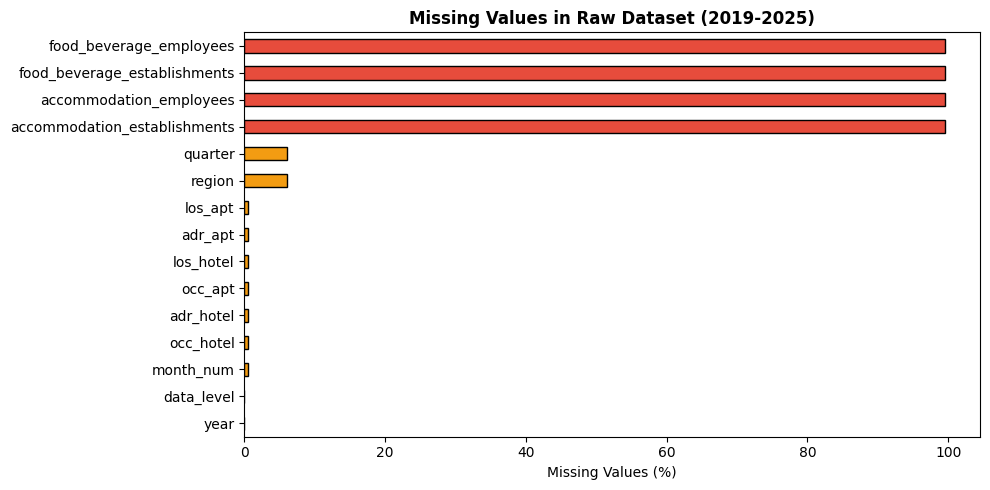


Breakdown by year:
  2019: 1 rows | occ_hotel NaN: 1 | region NaN: 1
  2020: 1 rows | occ_hotel NaN: 1 | region NaN: 1
  2021: 12 rows | occ_hotel NaN: 0 | region NaN: 12
  2022: 12 rows | occ_hotel NaN: 0 | region NaN: 12
  2023: 156 rows | occ_hotel NaN: 0 | region NaN: 0
  2024: 156 rows | occ_hotel NaN: 0 | region NaN: 0
  2025: 90 rows | occ_hotel NaN: 0 | region NaN: 0


In [ ]:
print("=" * 55)
print("MISSING VALUES IN RAW DATA")
print("=" * 55)

for col in df_raw.columns:
    missing = df_raw[col].isna().sum()
    if missing > 0:
        pct = missing / len(df_raw) * 100
        print(f"  {col:<40} {missing:>3} missing ({pct:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=True)
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 0 else '#2ecc71' for x in missing_pct]
missing_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Values in Raw Dataset (2019-2025)', fontweight='bold')
plt.tight_layout()
plt.show()

# By year
print("\nBreakdown by year:")
for year in sorted(df_raw['year'].unique()):
    yr = df_raw[df_raw['year'] == year]
    print(f"  {year}: {len(yr)} rows | occ_hotel NaN: {yr['occ_hotel'].isna().sum()} | region NaN: {yr['region'].isna().sum()}")

##  Step 4: Feature Selection — Drop Columns with >90% Missing

In [ ]:
drop_cols = []
for col in df_raw.columns:
    pct = df_raw[col].isna().sum() / len(df_raw) * 100
    if pct > 90:
        drop_cols.append(col)
        print(f"  DROPPING: {col} ({pct:.1f}% missing)")

df = df_raw.drop(columns=drop_cols).copy()
print(f"\nColumns reduced: {df_raw.shape[1]} → {df.shape[1]}")

  DROPPING: accommodation_establishments (99.5% missing)
  DROPPING: accommodation_employees (99.5% missing)
  DROPPING: food_beverage_establishments (99.5% missing)
  DROPPING: food_beverage_employees (99.5% missing)

Columns reduced: 15 → 11


## Step 5: Handle Missing Values

In [ ]:

print("Rows with missing target (occ_hotel):", df['occ_hotel'].isna().sum())
print("  From years:", df[df['occ_hotel'].isna()]['year'].unique())
print("  Decision: DROP — cannot impute the target variable")
df = df.dropna(subset=['occ_hotel'])
print(f"  Rows after drop: {len(df)}")


print(f"\nRows with missing region: {df['region'].isna().sum()}")
print("  Decision: FILL with 'National' label")
df['region'] = df['region'].fillna('National')


def get_quarter(m):
    if pd.isna(m): return np.nan
    m = int(m)
    if m <= 3: return 'Q1'
    elif m <= 6: return 'Q2'
    elif m <= 9: return 'Q3'
    else: return 'Q4'

df['quarter'] = df.apply(lambda r: r['quarter'] if pd.notna(r['quarter']) else get_quarter(r['month_num']), axis=1)

print(f"\n✅ Final missing values: {df.isnull().sum().sum()}")
print(f"✅ Dataset: {len(df)} rows")

Rows with missing target (occ_hotel): 2
  From years: [2019 2020]
  Decision: DROP — cannot impute the target variable
  Rows after drop: 426

Rows with missing region: 24
  Decision: FILL with 'National' label

✅ Final missing values: 0
✅ Dataset: 426 rows


##  Step 6: Duplicate Detection

In [ ]:
dupes = df.duplicated(subset=['year', 'month_num', 'region']).sum()
print(f"Duplicate records: {dupes}")

Duplicate records: 0


##  Step 7: Outlier Detection (IQR Method)

occ_hotel: 3 outliers (range: 0.080 to 0.844)
  Regions: ['Madinah']
  Decision: KEEP — real demand peaks

adr_hotel: 32 outliers (range: -40.932 to 770.863)
  Regions: ['Riyadh', 'Makkah', 'Madinah', 'Aseer', 'Hail', 'Tabuk']
  Decision: KEEP — real demand peaks

los_hotel: 32 outliers (range: -0.070 to 4.681)
  Regions: ['National', 'Najran', 'Makkah', 'Madinah']
  Decision: KEEP — real demand peaks



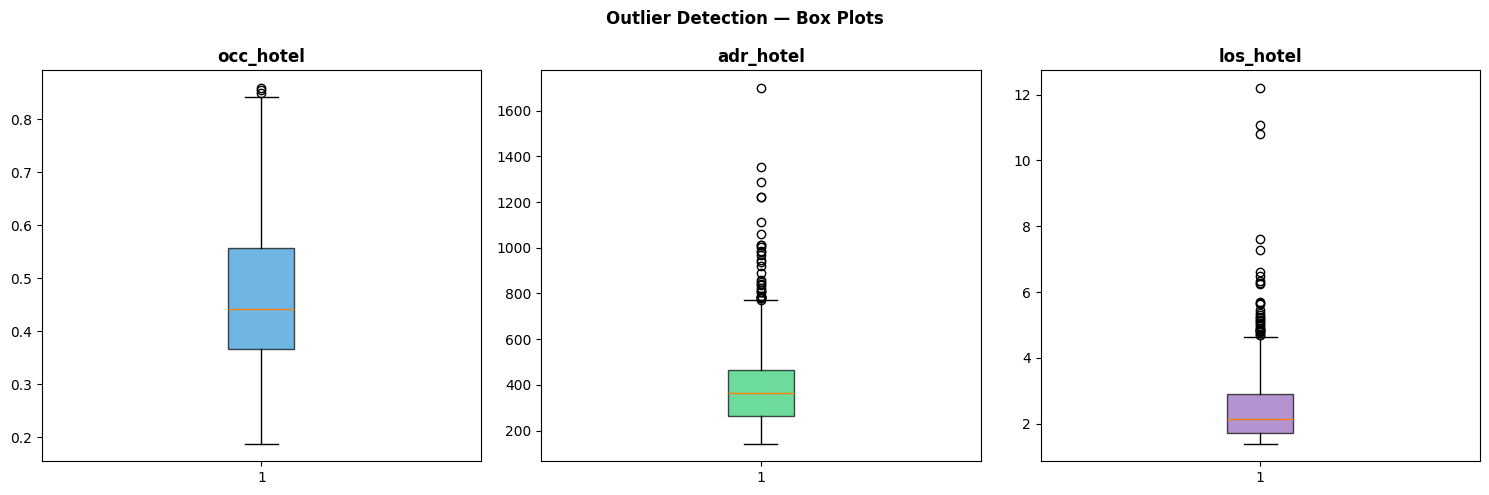

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['occ_hotel', 'adr_hotel', 'los_hotel']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers (range: {lower:.3f} to {upper:.3f})")
    if len(outliers) > 0:
        print(f"  Regions: {list(outliers['region'].unique())}")
    print(f"  Decision: KEEP — real demand peaks\n")

    bp = axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor(['#3498db', '#2ecc71', '#9467bd'][i])
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Outlier Detection — Box Plots', fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 8: Log Transformation (ADR Skewness Fix)

ADR skewness BEFORE: 1.87
ADR skewness AFTER:  0.39


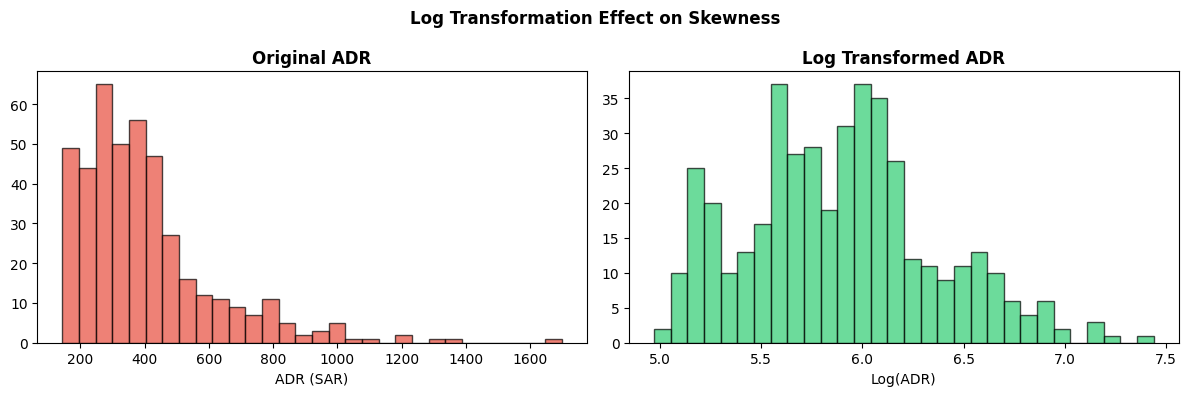

In [ ]:
print(f"ADR skewness BEFORE: {df['adr_hotel'].skew():.2f}")
df['log_adr_hotel'] = np.log1p(df['adr_hotel'])
df['log_adr_apt'] = np.log1p(df['adr_apt'])
print(f"ADR skewness AFTER:  {df['log_adr_hotel'].skew():.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df['adr_hotel'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
ax1.set_title('Original ADR', fontweight='bold'); ax1.set_xlabel('ADR (SAR)')

ax2.hist(df['log_adr_hotel'], bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
ax2.set_title('Log Transformed ADR', fontweight='bold'); ax2.set_xlabel('Log(ADR)')

plt.suptitle('Log Transformation Effect on Skewness', fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 9: Feature Engineering

In [ ]:
df['quarter_num'] = df['quarter'].str.replace('Q', '').astype(int)
df['sin_month'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month_num'] / 12)

# Hijri calendar features
hajj_months = {2021:[7,8], 2022:[7], 2023:[6,7], 2024:[6], 2025:[6]}
ramadan_months = {2021:[4,5], 2022:[4], 2023:[3,4], 2024:[3,4], 2025:[2,3]}

df['is_hajj'] = df.apply(lambda r: 1 if int(r['month_num']) in hajj_months.get(int(r['year']),[]) else 0, axis=1)
df['is_ramadan'] = df.apply(lambda r: 1 if int(r['month_num']) in ramadan_months.get(int(r['year']),[]) else 0, axis=1)
df['is_riyadh_season'] = df['month_num'].apply(lambda m: 1 if int(m) in [10,11,12,1,2,3] else 0)
df['is_summer'] = df['month_num'].apply(lambda m: 1 if int(m) in [7,8] else 0)

le = LabelEncoder()
df['region_encoded'] = le.fit_transform(df['region'])

print("✅ Engineered features:")
print("  Temporal: sin_month, cos_month, quarter_num")
print("  Hijri: is_hajj, is_ramadan")
print("  Events: is_riyadh_season, is_summer")
print("  Region: region_encoded")
print(f"\nFinal dataset: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Engineered features:
  Temporal: sin_month, cos_month, quarter_num
  Hijri: is_hajj, is_ramadan
  Events: is_riyadh_season, is_summer
  Region: region_encoded

Final dataset: 426 rows × 21 columns


##  Step 10: Feature Correlation

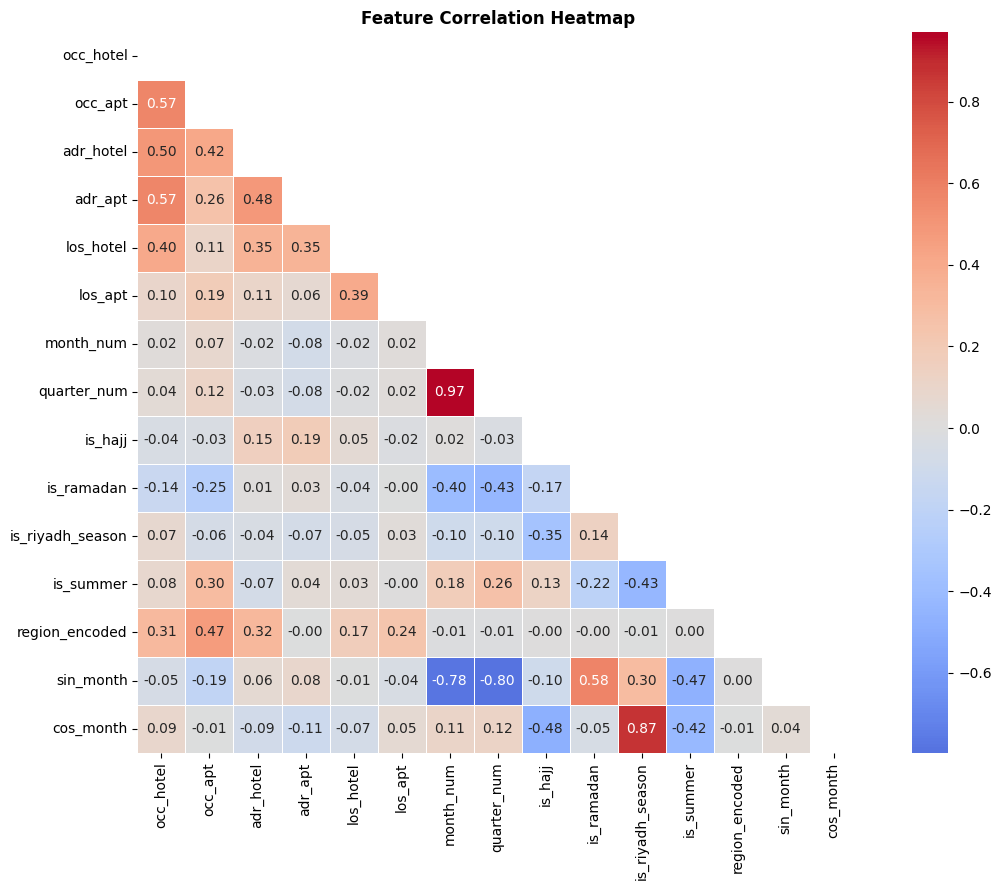

In [ ]:
feature_cols = ['occ_hotel','occ_apt','adr_hotel','adr_apt','los_hotel','los_apt',
                'month_num','quarter_num','is_hajj','is_ramadan','is_riyadh_season',
                'is_summer','region_encoded','sin_month','cos_month']
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 11: Train-Test Split
Using regional data only (2023-2025). National data from 2021-2022 is excluded from modeling because it has no regional breakdown.

In [ ]:
df_model = df[df['data_level'] == 'Regional'].copy()

feature_names = ['log_adr_hotel','los_hotel','occ_apt','log_adr_apt',
                 'month_num','quarter_num','sin_month','cos_month',
                 'is_hajj','is_ramadan','is_riyadh_season','is_summer',
                 'region_encoded','year']

X = df_model[feature_names].values
y = df_model['occ_hotel'].values

train_mask = df_model['year'].isin([2023, 2024])
test_mask = df_model['year'] == 2025

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Regional modeling subset: {len(df_model)} rows")
print(f"Train: {X_train.shape[0]} samples (2023-2024)")
print(f"Test:  {X_test.shape[0]} samples (2025)")
print(f"Features: {len(feature_names)}")

Regional modeling subset: 402 rows
Train: 312 samples (2023-2024)
Test:  90 samples (2025)
Features: 14


---
#  MODEL TRAINING AND EVALUATION
---

## Model 1: Linear Regression (Baseline)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print("=" * 50)
print("MODEL 1: LINEAR REGRESSION (Baseline)")
print("=" * 50)
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  MAE:  {mae_lr:.4f}")
print(f"  R²:   {r2_lr:.4f}")
print(f"  MAPE: {mape_lr:.1f}%")

MODEL 1: LINEAR REGRESSION (Baseline)
  RMSE: 0.1068
  MAE:  0.0854
  R²:   0.3651
  MAPE: 17.6%


## Model 2: Decision Tree

In [ ]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100

print("=" * 50)
print("MODEL 2: DECISION TREE")
print("  Config: max_depth=8, min_samples_leaf=5")
print("=" * 50)
print(f"  RMSE: {rmse_dt:.4f}")
print(f"  MAE:  {mae_dt:.4f}")
print(f"  R²:   {r2_dt:.4f}")
print(f"  MAPE: {mape_dt:.1f}%")

MODEL 2: DECISION TREE
  Config: max_depth=8, min_samples_leaf=5
  RMSE: 0.0710
  MAE:  0.0547
  R²:   0.7199
  MAPE: 12.3%


## Model 3: Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("=" * 50)
print("MODEL 3: RANDOM FOREST")
print("  Config: 200 trees, max_depth=10, min_samples_leaf=3")
print("=" * 50)
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")
print(f"  MAPE: {mape_rf:.1f}%")

MODEL 3: RANDOM FOREST
  Config: 200 trees, max_depth=10, min_samples_leaf=3
  RMSE: 0.0708
  MAE:  0.0538
  R²:   0.7211
  MAPE: 11.4%


## Model 4: Gradient Boosting 

In [ ]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
mape_gb = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

print("=" * 50)
print("⭐ MODEL 4: GRADIENT BOOSTING (BEST)")
print("  Config: 200 trees, max_depth=5, learning_rate=0.1")
print("=" * 50)
print(f"  RMSE: {rmse_gb:.4f}")
print(f"  MAE:  {mae_gb:.4f}")
print(f"  R²:   {r2_gb:.4f}")
print(f"  MAPE: {mape_gb:.1f}%")

⭐ MODEL 4: GRADIENT BOOSTING (BEST)
  Config: 200 trees, max_depth=5, learning_rate=0.1
  RMSE: 0.0599
  MAE:  0.0449
  R²:   0.8006
  MAPE: 9.3%


---
# 📊 FULL COMPARISON
---

In [ ]:
print("=" * 70)
print("              ALL MODELS — PERFORMANCE COMPARISON")
print("=" * 70)
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'MAPE':>8}")
print("-" * 62)
print(f"{'Linear Regression':<25} {rmse_lr:>8.4f} {mae_lr:>8.4f} {r2_lr:>8.4f} {mape_lr:>7.1f}%")
print(f"{'Decision Tree':<25} {rmse_dt:>8.4f} {mae_dt:>8.4f} {r2_dt:>8.4f} {mape_dt:>7.1f}%")
print(f"{'Random Forest':<25} {rmse_rf:>8.4f} {mae_rf:>8.4f} {r2_rf:>8.4f} {mape_rf:>7.1f}%")
print(f"{'⭐ Gradient Boosting':<25} {rmse_gb:>8.4f} {mae_gb:>8.4f} {r2_gb:>8.4f} {mape_gb:>7.1f}%")
print("-" * 62)
print(f"\n⭐ Best Model: Gradient Boosting (R² = {r2_gb:.4f}, MAPE = {mape_gb:.1f}%)")

              ALL MODELS — PERFORMANCE COMPARISON
Model                         RMSE      MAE       R²     MAPE
--------------------------------------------------------------
Linear Regression           0.1068   0.0854   0.3651    17.6%
Decision Tree               0.0710   0.0547   0.7199    12.3%
Random Forest               0.0708   0.0538   0.7211    11.4%
⭐ Gradient Boosting         0.0599   0.0449   0.8006     9.3%
--------------------------------------------------------------

⭐ Best Model: Gradient Boosting (R² = 0.8006, MAPE = 9.3%)


## Visual Comparison — Bar Charts

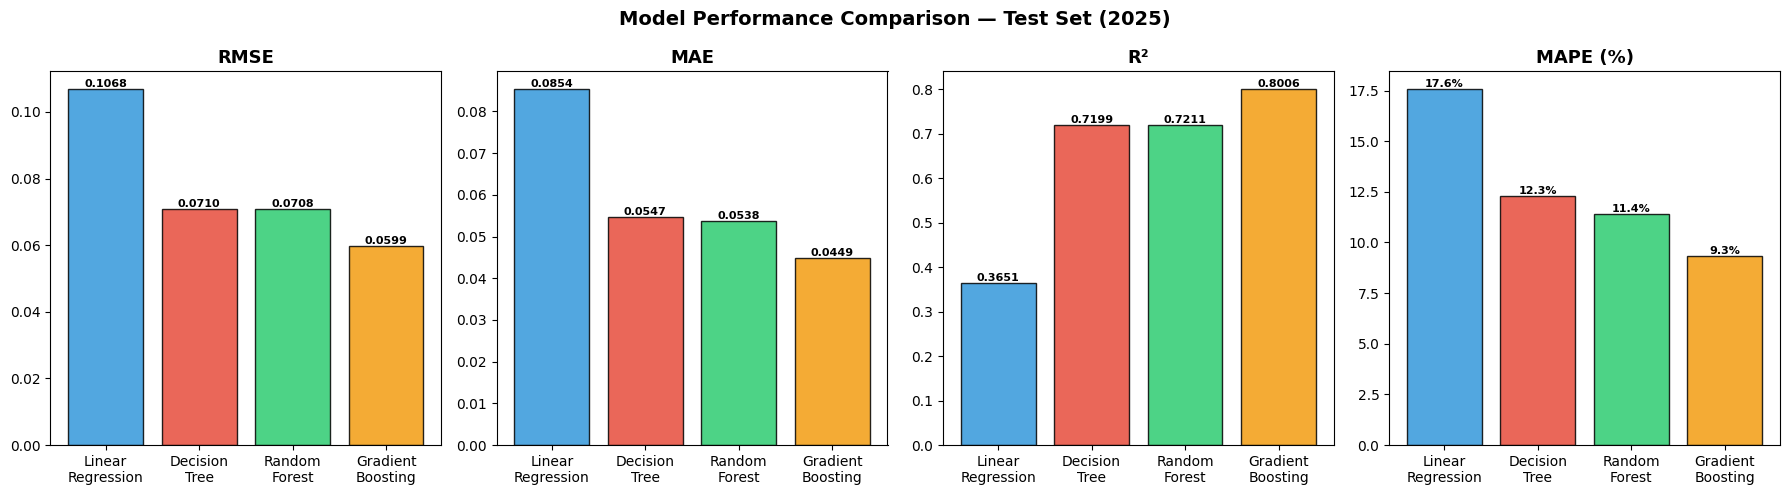

In [ ]:
models_names = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']
clrs = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = {
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_gb],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_gb],
    'R²': [r2_lr, r2_dt, r2_rf, r2_gb],
    'MAPE (%)': [mape_lr, mape_dt, mape_rf, mape_gb],
}
for i, (name, vals) in enumerate(metrics.items()):
    bars = axes[i].bar(models_names, vals, color=clrs, edgecolor='black', alpha=0.85)
    axes[i].set_title(name, fontweight='bold', fontsize=13)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if name != 'MAPE (%)' else f'{val:.1f}%'
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt, ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.suptitle('Model Performance Comparison — Test Set (2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Predicted vs Actual — Scatter Plots

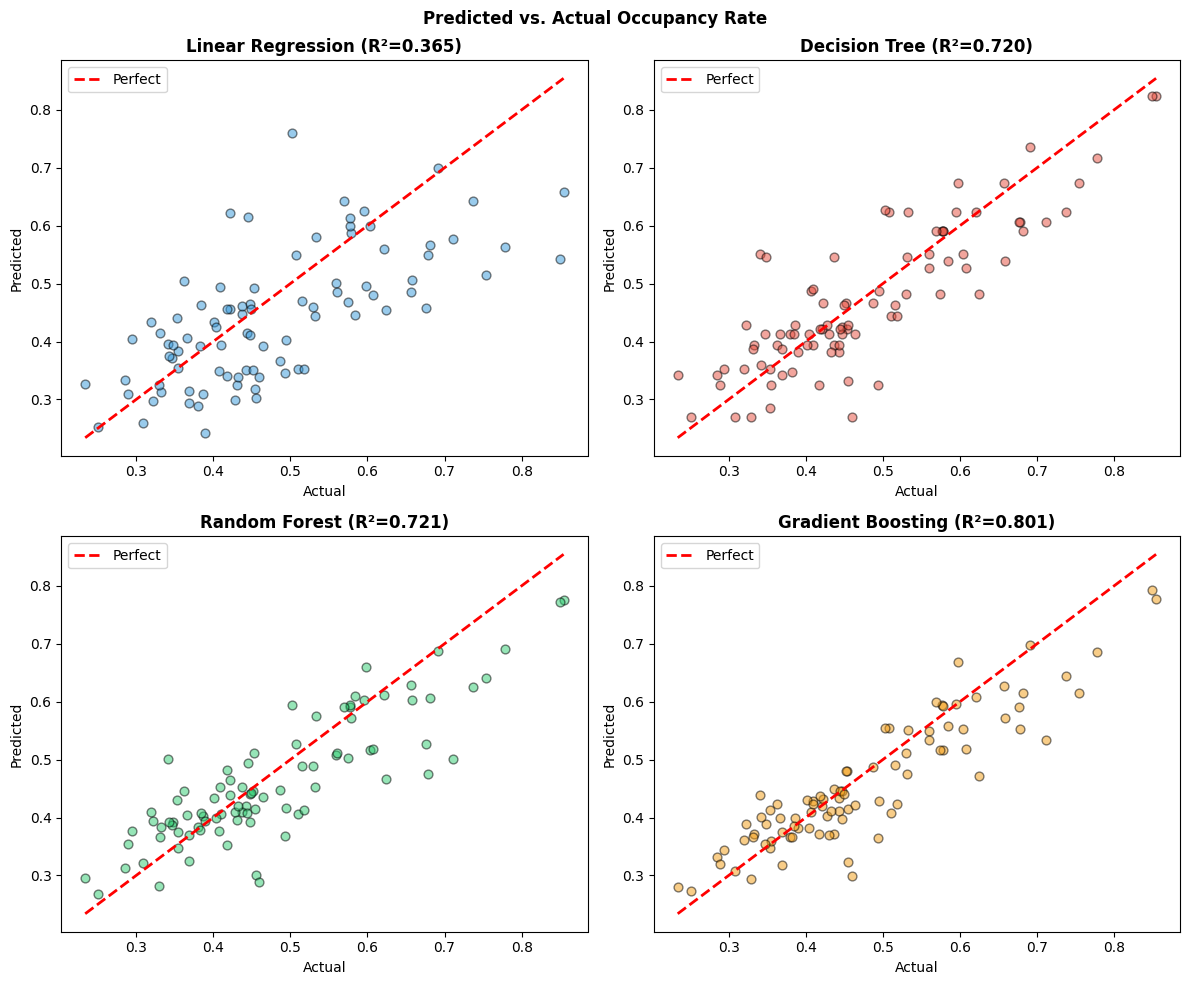

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
all_preds = {'Linear Regression':(y_pred_lr,r2_lr), 'Decision Tree':(y_pred_dt,r2_dt),
             'Random Forest':(y_pred_rf,r2_rf), 'Gradient Boosting':(y_pred_gb,r2_gb)}
clrs = ['#3498db','#e74c3c','#2ecc71','#f39c12']

for idx, (name, (yp, r2)) in enumerate(all_preds.items()):
    ax = axes[idx//2][idx%2]
    ax.scatter(y_test, yp, alpha=0.5, color=clrs[idx], edgecolors='black', s=40)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name} (R²={r2:.3f})', fontweight='bold')
    ax.legend()
plt.suptitle('Predicted vs. Actual Occupancy Rate', fontweight='bold')
plt.tight_layout()
plt.show()

## Residual Distribution

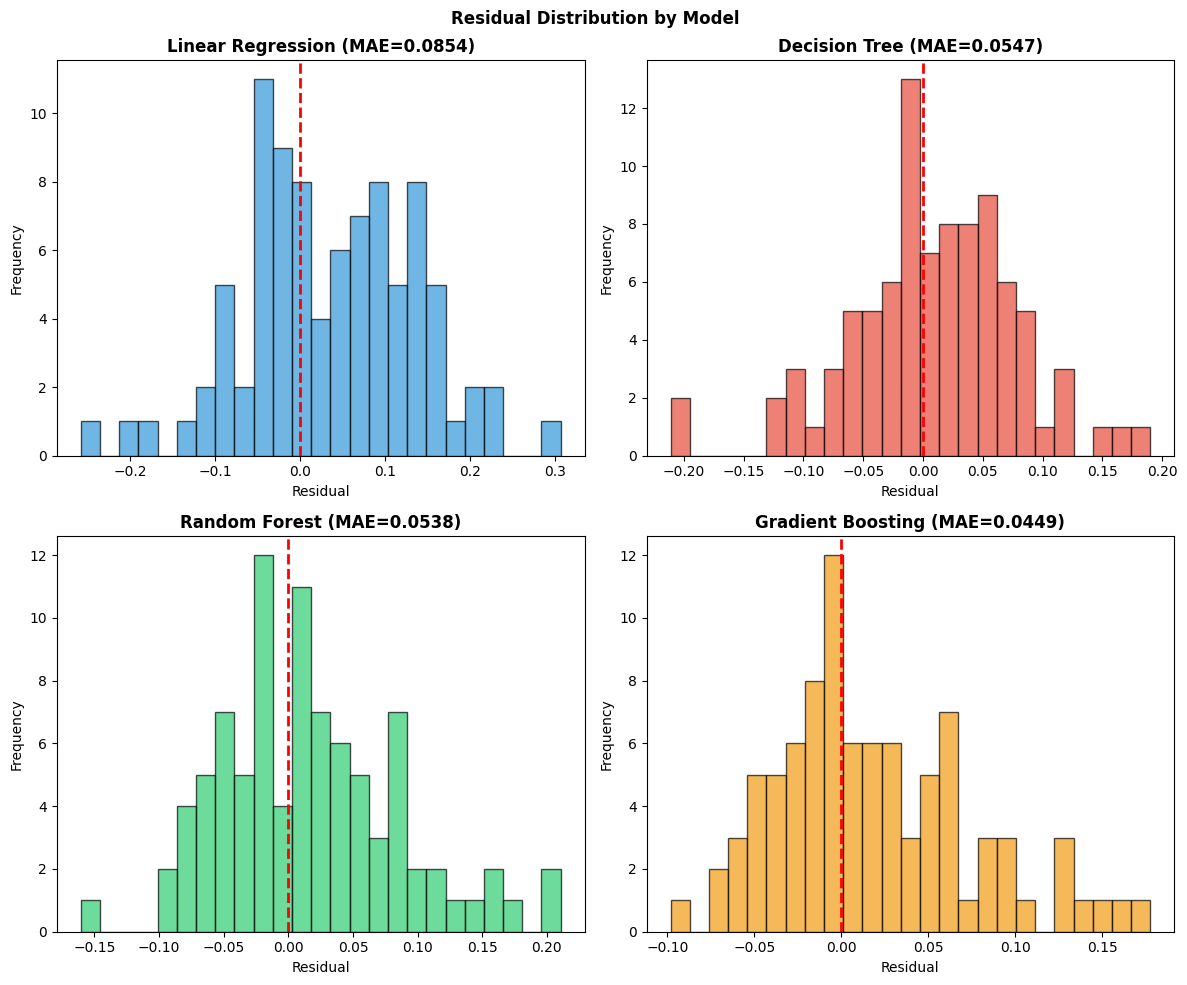

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
all_preds_list = [('Linear Regression',y_pred_lr,mae_lr), ('Decision Tree',y_pred_dt,mae_dt),
                  ('Random Forest',y_pred_rf,mae_rf), ('Gradient Boosting',y_pred_gb,mae_gb)]
for idx, (name, yp, mae) in enumerate(all_preds_list):
    ax = axes[idx//2][idx%2]
    ax.hist(y_test - yp, bins=25, color=clrs[idx], alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', ls='--', lw=2)
    ax.set_xlabel('Residual'); ax.set_ylabel('Frequency')
    ax.set_title(f'{name} (MAE={mae:.4f})', fontweight='bold')
plt.suptitle('Residual Distribution by Model', fontweight='bold')
plt.tight_layout()
plt.show()

## Cross-Validation (5-Fold Time Series)

Model                        Mean R²        Std
------------------------------------------------
Linear Regression             0.3147     0.3359
Decision Tree                 0.4919     0.1654
Random Forest                 0.7377     0.0844
Gradient Boosting             0.7148     0.1064


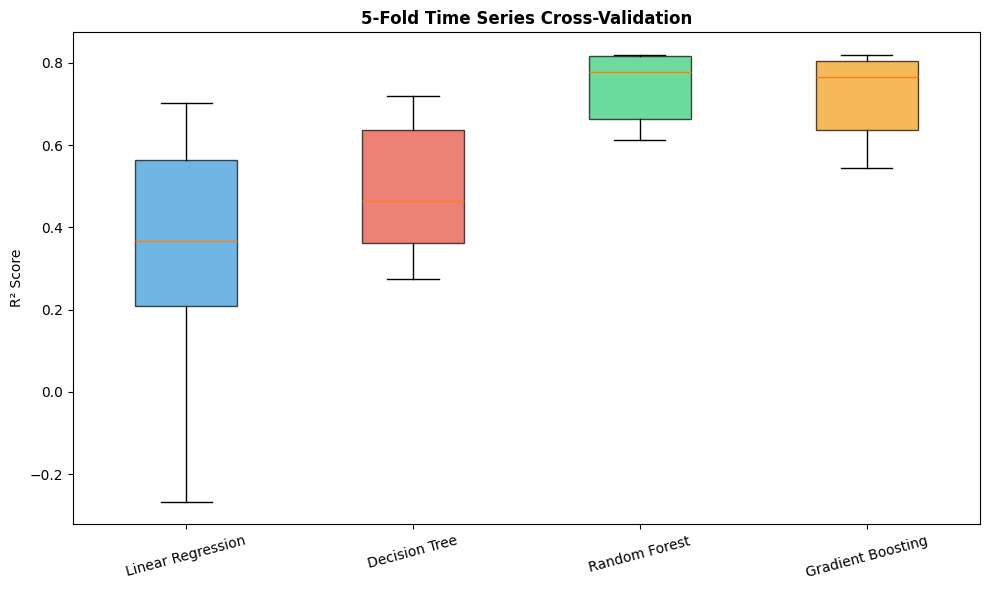

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
models_cv = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}
cv_scores = {}
print(f"{'Model':<25} {'Mean R²':>10} {'Std':>10}")
print("-" * 48)
for name, model in models_cv.items():
    Xc = X_train_scaled if name == 'Linear Regression' else X_train
    scores = cross_val_score(model, Xc, y_train, cv=tscv, scoring='r2')
    cv_scores[name] = scores
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([cv_scores[m] for m in models_cv], labels=models_cv.keys(), patch_artist=True)
for patch, c in zip(bp['boxes'], clrs): patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel('R² Score'); ax.set_title('5-Fold Time Series Cross-Validation', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##  Feature Importance (Gradient Boosting)

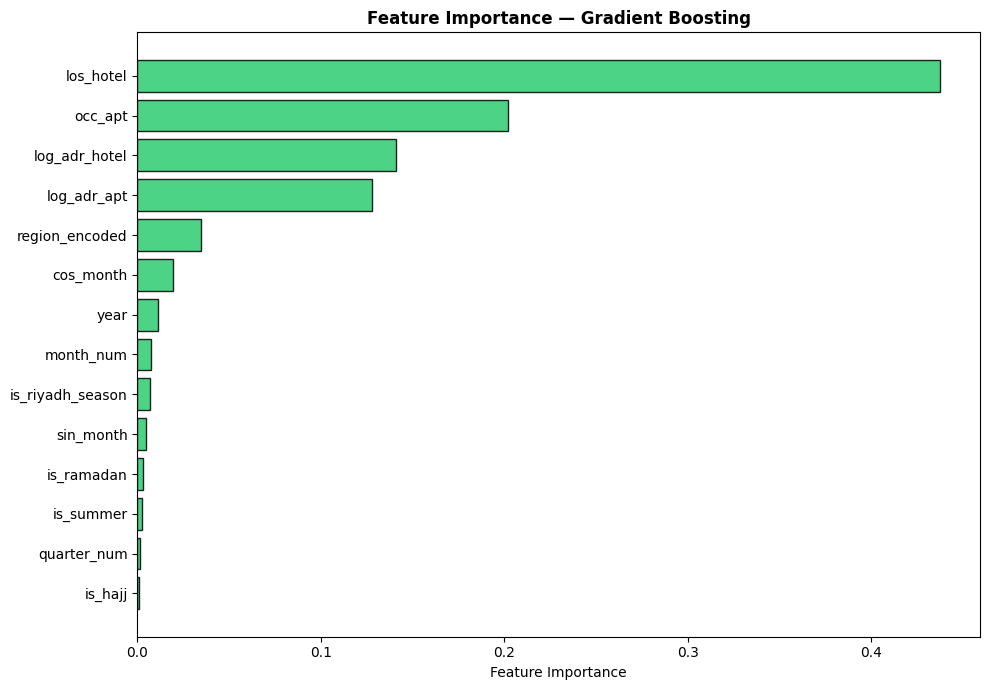


Feature Importance Ranking:
----------------------------------------
  los_hotel                 43.7%
  occ_apt                   20.2%
  log_adr_hotel             14.1%
  log_adr_apt               12.8%
  region_encoded            3.5%
  cos_month                 2.0%
  year                      1.1%
  month_num                 0.7%
  is_riyadh_season          0.7%
  sin_month                 0.4%
  is_ramadan                0.3%
  is_summer                 0.2%
  quarter_num               0.1%
  is_hajj                   0.1%


In [ ]:
fi = pd.DataFrame({'Feature': feature_names, 'Importance': gb.feature_importances_})
fi = fi.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi['Feature'], fi['Importance'], color='#2ecc71', edgecolor='black', alpha=0.85)
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — Gradient Boosting', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print("-" * 40)
for _, row in fi.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:<25} {row['Importance']*100:.1f}%")

##  Actual vs Predicted — Key Regions (2025)

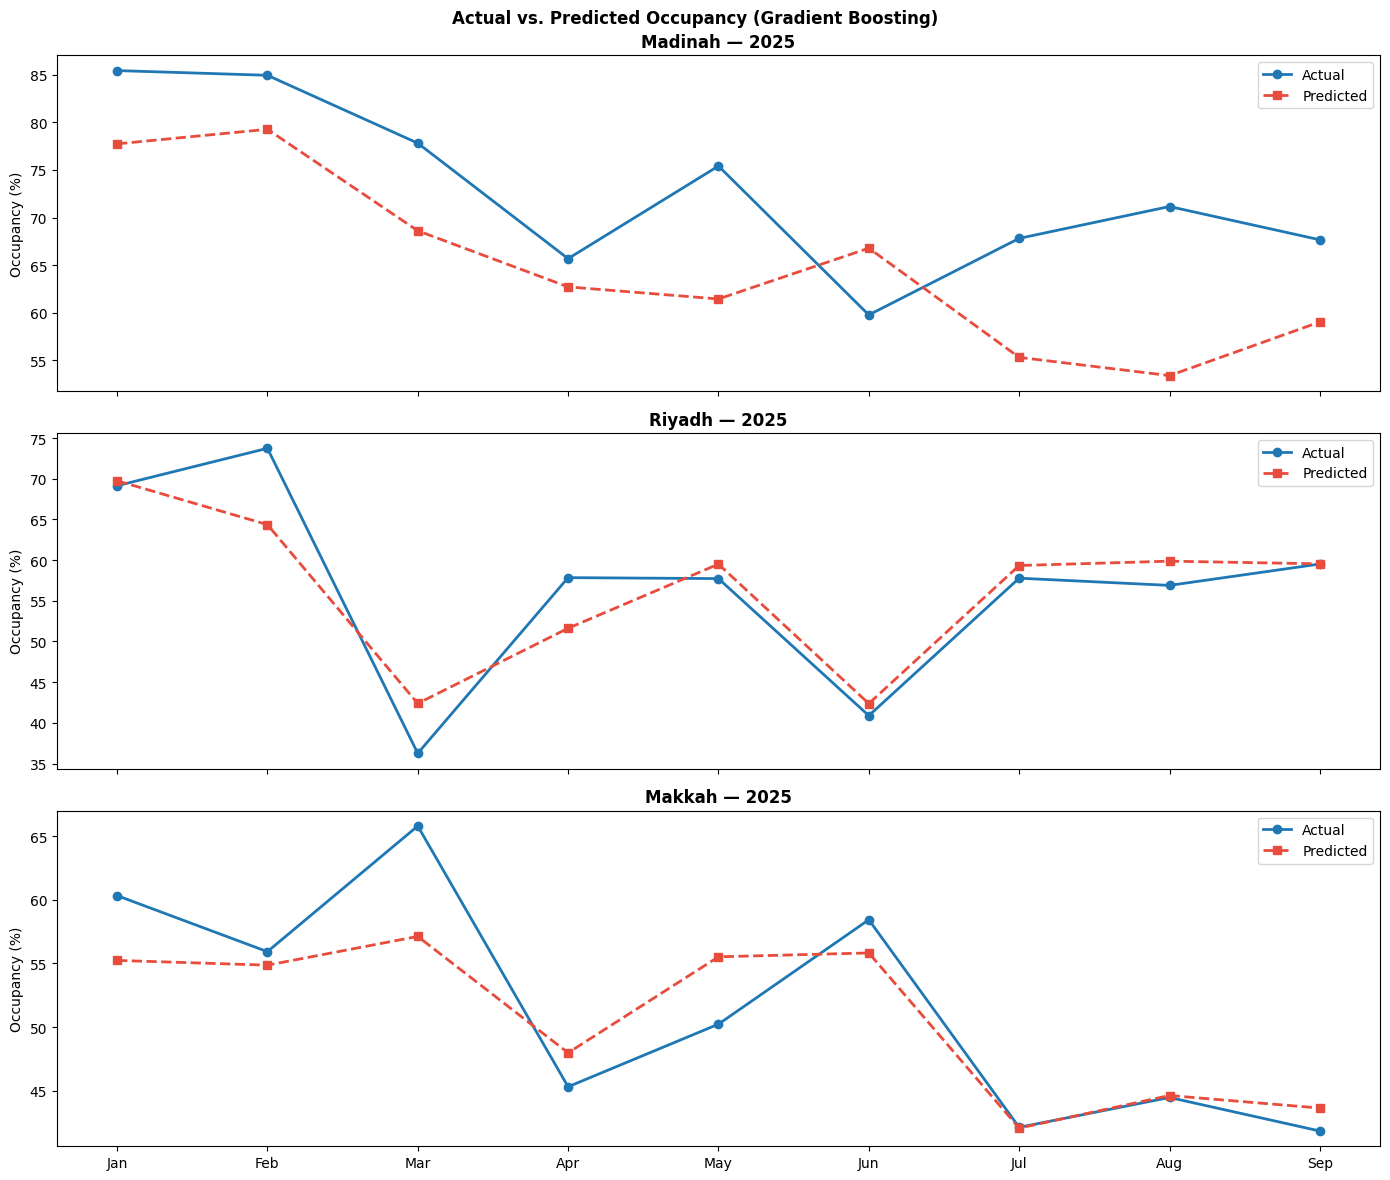

In [ ]:
test_df = df_model[test_mask].copy()
test_df['predicted'] = y_pred_gb

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for i, region in enumerate(['Madinah', 'Riyadh', 'Makkah']):
    rdf = test_df[test_df['region']==region].sort_values('month_num')
    axes[i].plot(rdf['month_num'], rdf['occ_hotel']*100, 'o-', color='#1f77b4', lw=2, ms=6, label='Actual')
    axes[i].plot(rdf['month_num'], rdf['predicted']*100, 's--', color='#e74c3c', lw=2, ms=6, label='Predicted')
    axes[i].set_ylabel('Occupancy (%)'); axes[i].set_title(f'{region} — 2025', fontweight='bold')
    axes[i].legend()
axes[2].set_xticks(range(1,10))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'])
plt.suptitle('Actual vs. Predicted Occupancy (Gradient Boosting)', fontweight='bold')
plt.tight_layout()
plt.show()

##  Prediction Error by Region

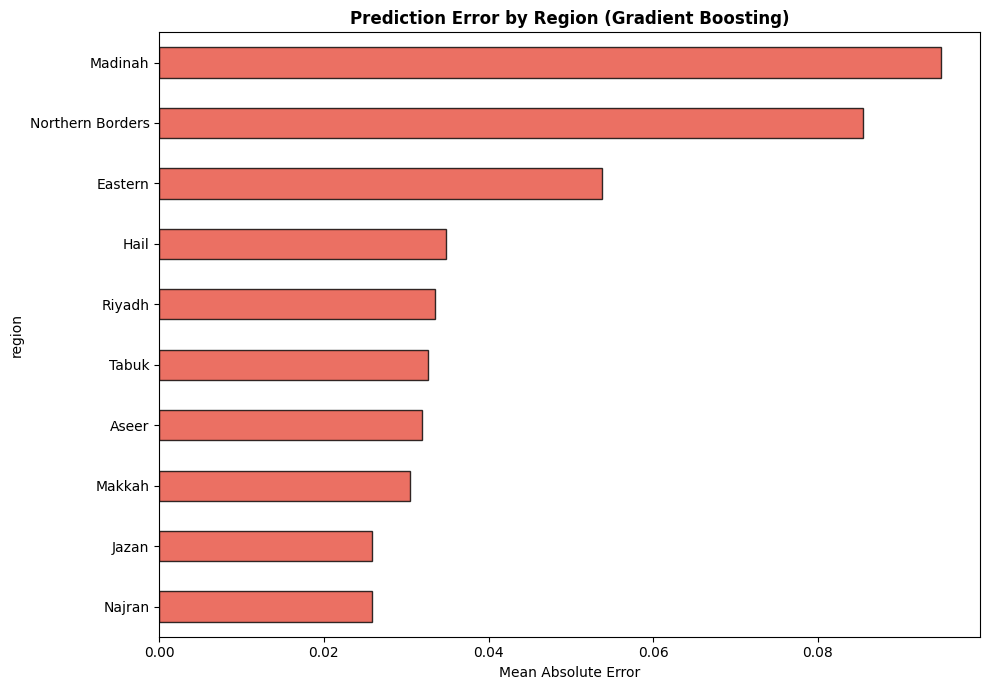


Error by Region:
----------------------------------------
  Najran               MAE: 0.0259 (2.6%)
  Jazan                MAE: 0.0259 (2.6%)
  Makkah               MAE: 0.0305 (3.0%)
  Aseer                MAE: 0.0319 (3.2%)
  Tabuk                MAE: 0.0327 (3.3%)
  Riyadh               MAE: 0.0335 (3.4%)
  Hail                 MAE: 0.0348 (3.5%)
  Eastern              MAE: 0.0538 (5.4%)
  Northern Borders     MAE: 0.0855 (8.5%)
  Madinah              MAE: 0.0949 (9.5%)


In [ ]:
test_df['abs_error'] = np.abs(test_df['occ_hotel'] - test_df['predicted'])
region_errors = test_df.groupby('region')['abs_error'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
region_errors.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_xlabel('Mean Absolute Error')
ax.set_title('Prediction Error by Region (Gradient Boosting)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nError by Region:")
print("-" * 40)
for region, err in region_errors.items():
    print(f"  {region:<20} MAE: {err:.4f} ({err*100:.1f}%)")

---
# FINAL SUMMARY

In [ ]:
print("=" * 60)
print("           FINAL SUMMARY")
print("=" * 60)
print(f"\nPreprocessing:")
print(f"  Raw data:         428 rows × 15 cols (2019-2025)")
print(f"  After cleaning:   {len(df)} rows × {len(df.columns)} cols (2021-2025)")
print(f"  Modeling subset:  {len(df_model)} rows (Regional, 2023-2025)")
print(f"  Dropped:          2 rows (2019-2020, target NaN)")
print(f"  Filled:           24 region NaN → 'National'")
print(f"  Dropped columns:  4 (>99% missing)")
print(f"  New features:     10 engineered")
print(f"\nModel Results:")
print(f"  {'Model':<25} {'R²':>8} {'MAPE':>8}")
print(f"  {'-'*43}")
print(f"  {'Linear Regression':<25} {r2_lr:>8.4f} {mape_lr:>7.1f}%")
print(f"  {'Decision Tree':<25} {r2_dt:>8.4f} {mape_dt:>7.1f}%")
print(f"  {'Random Forest':<25} {r2_rf:>8.4f} {mape_rf:>7.1f}%")
print(f"  {'⭐ Gradient Boosting':<25} {r2_gb:>8.4f} {mape_gb:>7.1f}%")
print(f"\n⭐ Best: Gradient Boosting — R² = {r2_gb:.4f}, MAPE = {mape_gb:.1f}%")
print(f"   Meaning: predictions are accurate to within ~{mape_gb:.0f}% on average")
print("=" * 60)

           FINAL SUMMARY

Preprocessing:
  Raw data:         428 rows × 15 cols (2019-2025)
  After cleaning:   426 rows × 21 cols (2021-2025)
  Modeling subset:  402 rows (Regional, 2023-2025)
  Dropped:          2 rows (2019-2020, target NaN)
  Filled:           24 region NaN → 'National'
  Dropped columns:  4 (>99% missing)
  New features:     10 engineered

Model Results:
  Model                           R²     MAPE
  -------------------------------------------
  Linear Regression           0.3651    17.6%
  Decision Tree               0.7199    12.3%
  Random Forest               0.7211    11.4%
  ⭐ Gradient Boosting         0.8006     9.3%

⭐ Best: Gradient Boosting — R² = 0.8006, MAPE = 9.3%
   Meaning: predictions are accurate to within ~9% on average
